In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import kind
import ex_duffing
import reinforcement_learning as rl
import util_data

In [2]:
# --! define a reward function --!

state_ndim = 2
action_ndim = 1

state_cost = 1.0 * np.eye(state_ndim)
action_cost = 10.0 * np.eye(action_ndim)

setpoint = [1.0, 0.0]

In [3]:
dt = 1e-2

reward_nom = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, beta=1.0, lambda_E=0.05)
reward_exc = ex_duffing.duffing_reward(state_cost, action_cost, setpoint, alpha=-60.0, beta=80.0, lambda_E=0.1)

duffing_nom = ex_duffing.duffing_adapter(ex_duffing.make_duffing('nom', reward_nom, dt=dt))
duffing_exc = ex_duffing.duffing_adapter(ex_duffing.make_duffing('exc', reward_exc, dt=dt))

In [4]:
# --! make a base policy --!

base_policy = ex_duffing.make_base_policy(
    duffing_nom.env.alpha, duffing_nom.env.delta,
    q=state_cost, r=action_cost,
    dt=dt,
    setpoint=setpoint)

In [5]:
factory = ex_duffing.replay_factory()

nsample = 48
residual_policy = None
zeta = 0.0
zeta_nom = kind.regimes(0, 0)
zeta_exc = kind.regimes(0, 0)

replay_nom = factory.create(duffing_nom, rl.policies(base_policy, residual_policy), zeta, zeta_nom, nsample, 11*nsample+6)#11*nsample+6
replay_exc = factory.create(duffing_exc, rl.policies(base_policy, residual_policy), zeta, zeta_exc, nsample, 11*nsample+6)

torch.Size([9466, 48, 4])
torch.Size([1, 9466, 4])


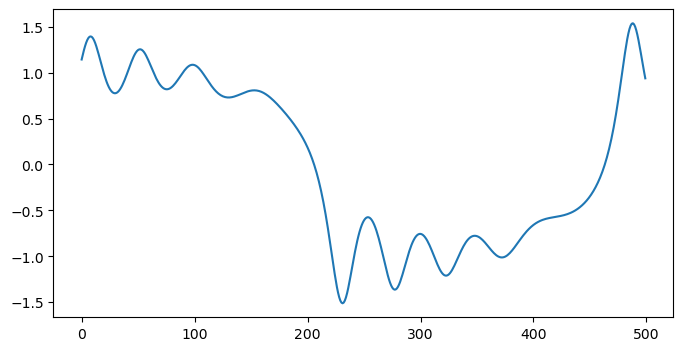

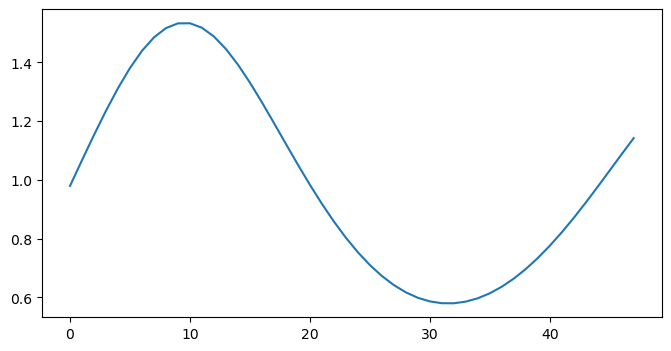

In [6]:
back_exc, _, _, _ = map(torch.cat, zip(*replay_exc.buffer))
s_exc = back_exc[:, [-1]]
s_exc = torch.transpose(s_exc, 0, 1)
print(back_exc.shape)
print(s_exc.shape)

with torch.no_grad():
    plt.figure(figsize=(8,4))

    plt.plot(s_exc[0, :500, 0])
    plt.show()

    plt.figure(figsize=(8,4))

    plt.plot(back_exc[0, :, 0])
    plt.show()


In [7]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '125',
        '--data_nsample_exc', '420',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.7',

        '--lookback_nsample', '48',
        '--forecast_nsample', '24',

        '--batch_size', '32',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '24',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 8}',
    ]
)

setpoint = [1.0, 0.0]

# --! instantiate a KIND model
model = kind.model(args)

# --! load trained weights into the model
model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=False)

model = kind.model_adapter(model, dataset.normalizer)

>>> regime separator is computed as 0.5400000214576721


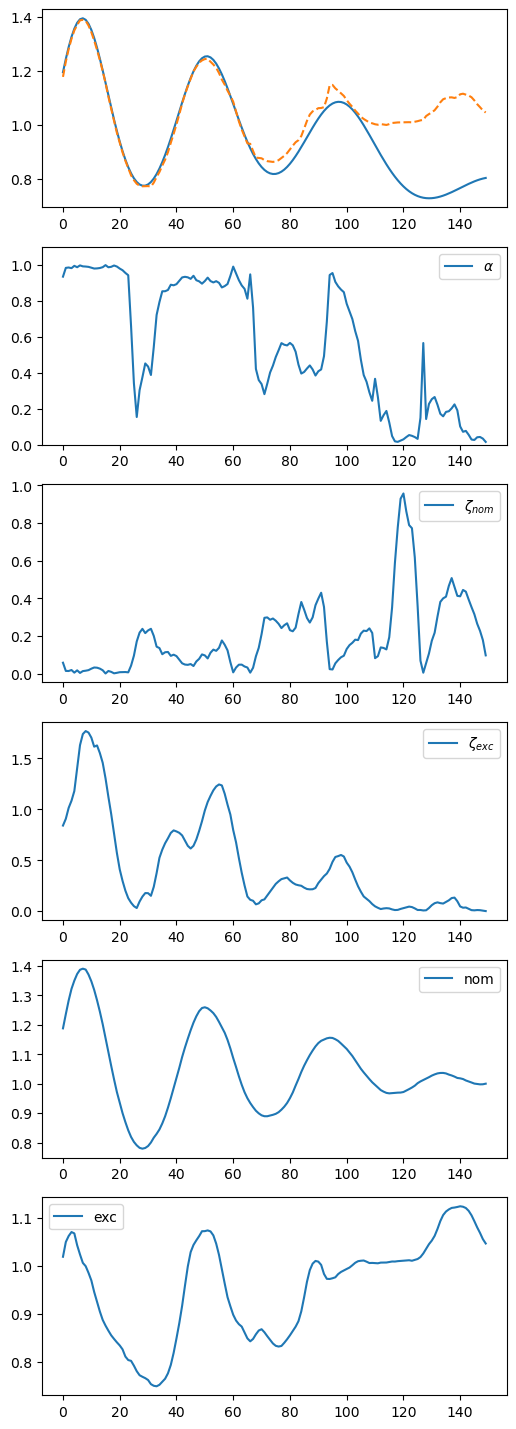

In [19]:
h = 150
next_ss = []
alphas = []
means_nom = []
means_exc = []
zetas_nom = []
zetas_exc = []

with torch.no_grad():

    true = s_exc[:, 1:h+1]

    back = back_exc[:1].clone()

    for k in range(h):
        s = factory.extract_current_s(back)
        a = base_policy(s)

        factory.update_current_a(back, a)
        model_o = model(back)

        fore = model_o.blend[:, args.lookback_nsample:]
        next_s = fore[:, :1]
        back = factory.update_state(back, next_s)

        alpha = model_o.alpha[:, args.lookback_nsample:]
        alpha = alpha[:, :1]

        zeta_nom = model_o.zeta_nom[:, args.lookback_nsample:]
        zeta_nom = zeta_nom[:, :1]

        zeta_exc = model_o.zeta_exc[:, args.lookback_nsample:]
        zeta_exc = zeta_exc[:, :1]

        mean_nom = model_o.mean_nom[:, args.lookback_nsample:]
        mean_nom = mean_nom[:, :1]

        mean_exc = model_o.mean_exc[:, args.lookback_nsample:]
        mean_exc = mean_exc[:, :1]

        next_ss.append(next_s)
        alphas.append(alpha)
        zetas_nom.append(zeta_nom)
        zetas_exc.append(zeta_exc)
        means_nom.append(mean_nom)
        means_exc.append(mean_exc)

    next_ss = torch.cat(next_ss, dim=1)
    alphas = torch.cat(alphas, dim=1)
    zetas_nom = torch.cat(zetas_nom, dim=1)
    zetas_exc = torch.cat(zetas_exc, dim=1)
    means_nom = torch.cat(means_nom, dim=1)
    means_exc = torch.cat(means_exc, dim=1)

    plt.figure(figsize=(6,18))

    plt.subplot(6,1,1)
    plt.plot(true[0, :, 0])
    plt.plot(next_ss[0, :, 0], linestyle='dashed')

    plt.subplot(6,1,2)
    plt.plot(alphas[0, :, 0], label='$\\alpha$')
    plt.ylim((0.0, 1.1))
    plt.legend()

    plt.subplot(6,1,3)
    plt.plot(zetas_nom[0, :, 0], label='$\\zeta_{nom}$')
    plt.legend()

    plt.subplot(6,1,4)
    plt.plot(zetas_exc[0, :, 0], label='$\\zeta_{exc}$')
    plt.legend()

    plt.subplot(6,1,5)
    plt.plot(means_nom[0, :, 0], label='nom')
    plt.legend()

    plt.subplot(6,1,6)
    plt.plot(means_exc[0, :, 0], label='exc')
    plt.legend()

    plt.show()
